In [1]:
import os
from tensorflow.keras import mixed_precision
#os.environ["CUDA_VISIBLE_DEVICES"] = "-1" #disable GPU, when active
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
mixed_precision.set_global_policy('mixed_float16') # set mixed precision policy for TensorFlow

2025-06-06 16:16:22.110330: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-06 16:16:22.134810: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-06 16:16:22.142010: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3060 Ti, compute capability 8.6


I0000 00:00:1749226585.462687   27561 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1749226585.547401   27561 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1749226585.547443   27561 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1749226585.547850   27561 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
import pathlib
import pickle
import time
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
from IPython import display
import tensorflow as tf


import utils_img_rec as ut
import discriminator as dis
import generator as gen

I0000 00:00:1749226585.914440   27561 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1749226585.914552   27561 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1749226585.914567   27561 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1749226586.089683   27561 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1749226586.089736   27561 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

In [3]:
data_path = "/tf/data_project/image/covid/pickle/covid19-radiography-pickle.pickle"
#data_path = "/tf/data_project/image/mnist/pickle/mnist_train-pickle.pickle"

out_path = "/tf/data_project/image/covid"
#out_path = "/tf/data_project/image/mnist"

train_image_out_path = out_path + "/train_generated_images"

model_save_path = out_path + '/models/generation_models'

checkpoint_dir = out_path + '/models/checkpoints'

log_dir = out_path + '/logs/fit/' + time.strftime("%Y%m%d-%H%M%S")


IMG_SIZE = 128
channels = 1

BUFFER_SIZE = 5545 # 60000 for mnist, 5545 for covid
BATCH_SIZE = 64

EPOCHS = 30
noise_dim = 100
num_examples_to_generate = 16

In [4]:
#extra_values = tf.constant([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0]])  # Tensor de shape (1,2)
extra_values = tf.constant([[0.0, 0.0, 1.0, 0.0]])

In [5]:
data_path = pathlib.Path(data_path)
out_path = pathlib.Path(out_path)
train_image_out_path = pathlib.Path(train_image_out_path)
model_save_path = pathlib.Path(model_save_path)
checkpoint_dir = pathlib.Path(checkpoint_dir)

In [6]:
pickle_in = open(data_path,"rb")
data_train = pickle.load(pickle_in)

In [7]:
CATEGORIES = ut.get_classes(data_train)
CATEGORIES.sort()
try:
    CATEGORIES.remove('.ipynb_checkpoints')
except:
    pass

print(CATEGORIES)
num_of_classes = len(CATEGORIES)
print(num_of_classes)

['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
4


In [8]:
print(ut.get_classes_plus_index(data_train))

{'COVID': 0, 'Lung_Opacity': 1, 'Normal': 2, 'Viral Pneumonia': 3}


In [9]:
train_X, train_y = ut.prep_data(data=data_train, CATEGORIES=CATEGORIES, IMG_SIZE=IMG_SIZE, num_of_channels=channels)
print('Entradas de treino - {} - ({}x{})'.format( train_X.shape[0], train_X.shape[1], train_X.shape[2] ))
print(train_X.shape)

Entradas de treino - 5545 - (128x128)
(5545, 128, 128, 1)


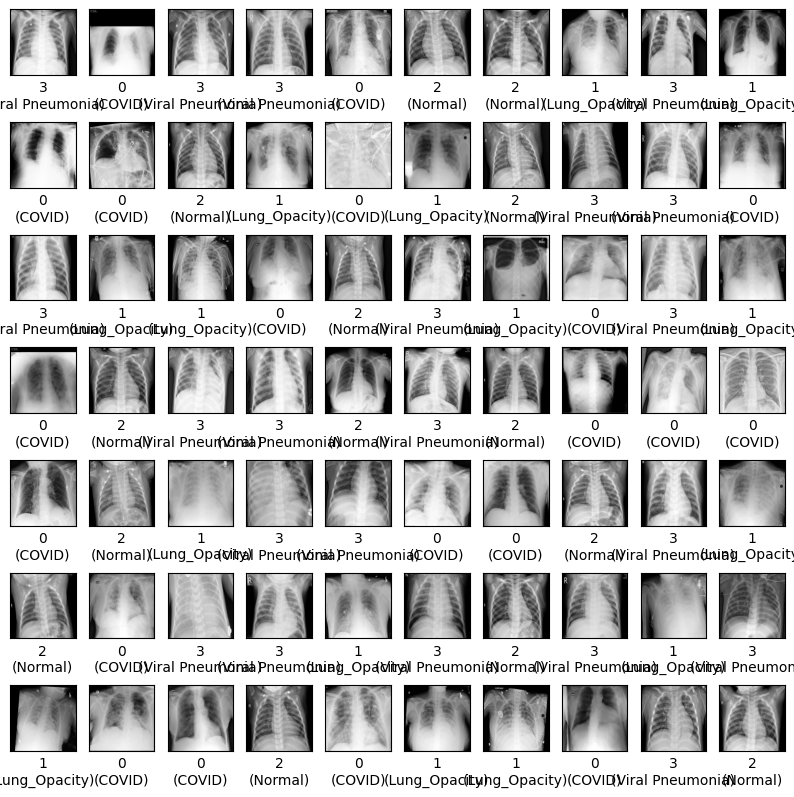

In [10]:
ut.plot_images(data_train)

In [11]:
train_images = np.array(train_X)
train_images = train_images.reshape(-1, IMG_SIZE, IMG_SIZE, 1).astype('float32')
train_images = (train_images - 127.5) / 127.5  # Normalize the images to [-1, 1]


train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_y))
train_dataset = train_dataset.shuffle(BUFFER_SIZE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

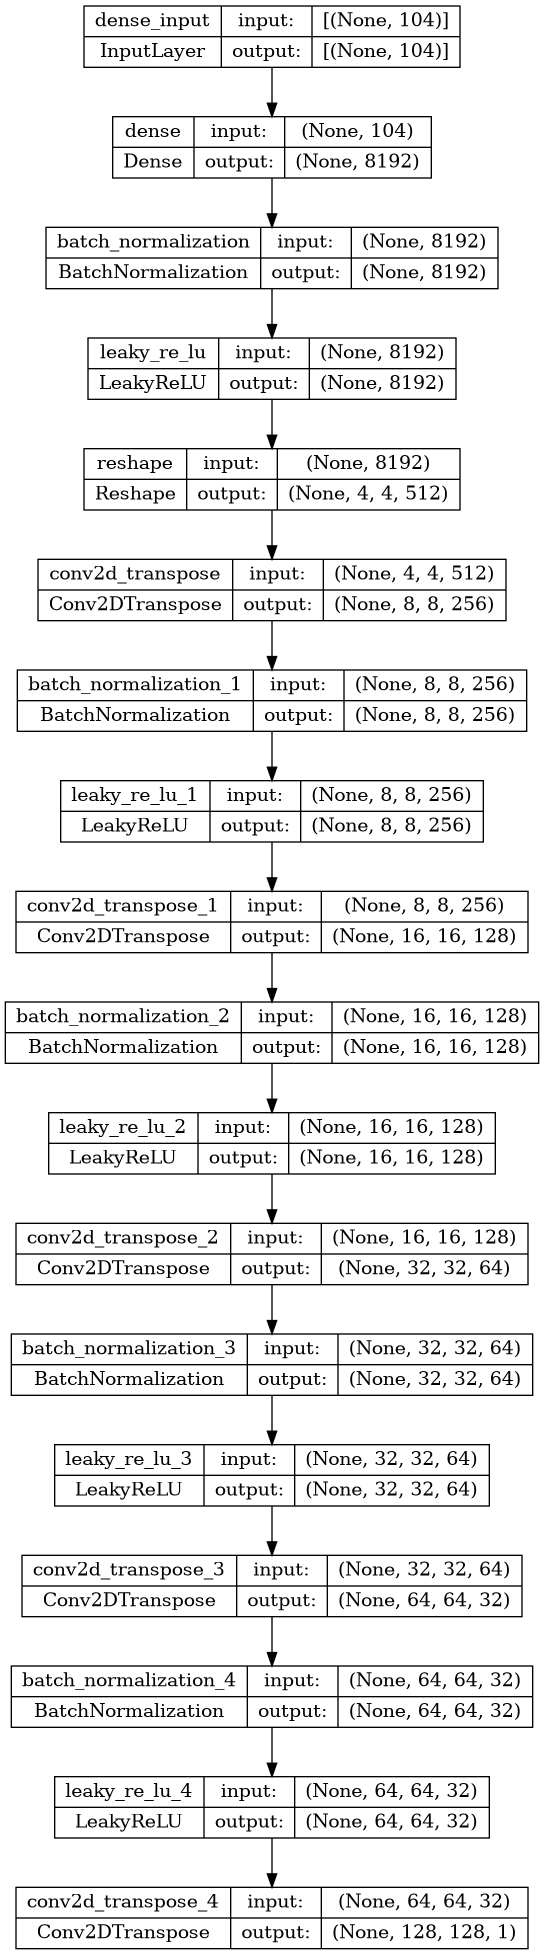

In [12]:
generator = gen.make_generator_model(noise_dim + num_of_classes, output_shape=(IMG_SIZE, IMG_SIZE, channels))
tf.keras.utils.plot_model(generator, show_shapes=True)

2025-06-06 16:16:30.818719: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
W0000 00:00:1749226591.169909   27561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1749226591.170359   27561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1749226591.170467   27561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1749226591.170615   27561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1749226591.171863   27561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduc

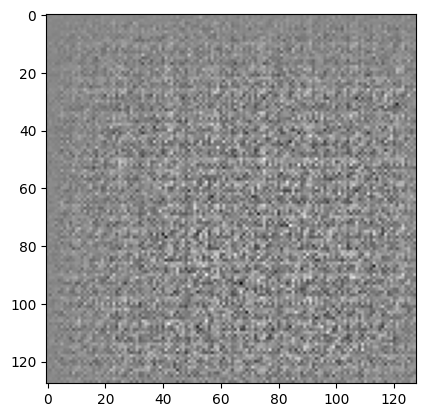

In [13]:
noise = tf.concat([tf.random.normal([1, noise_dim]), extra_values], axis=1)
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray')

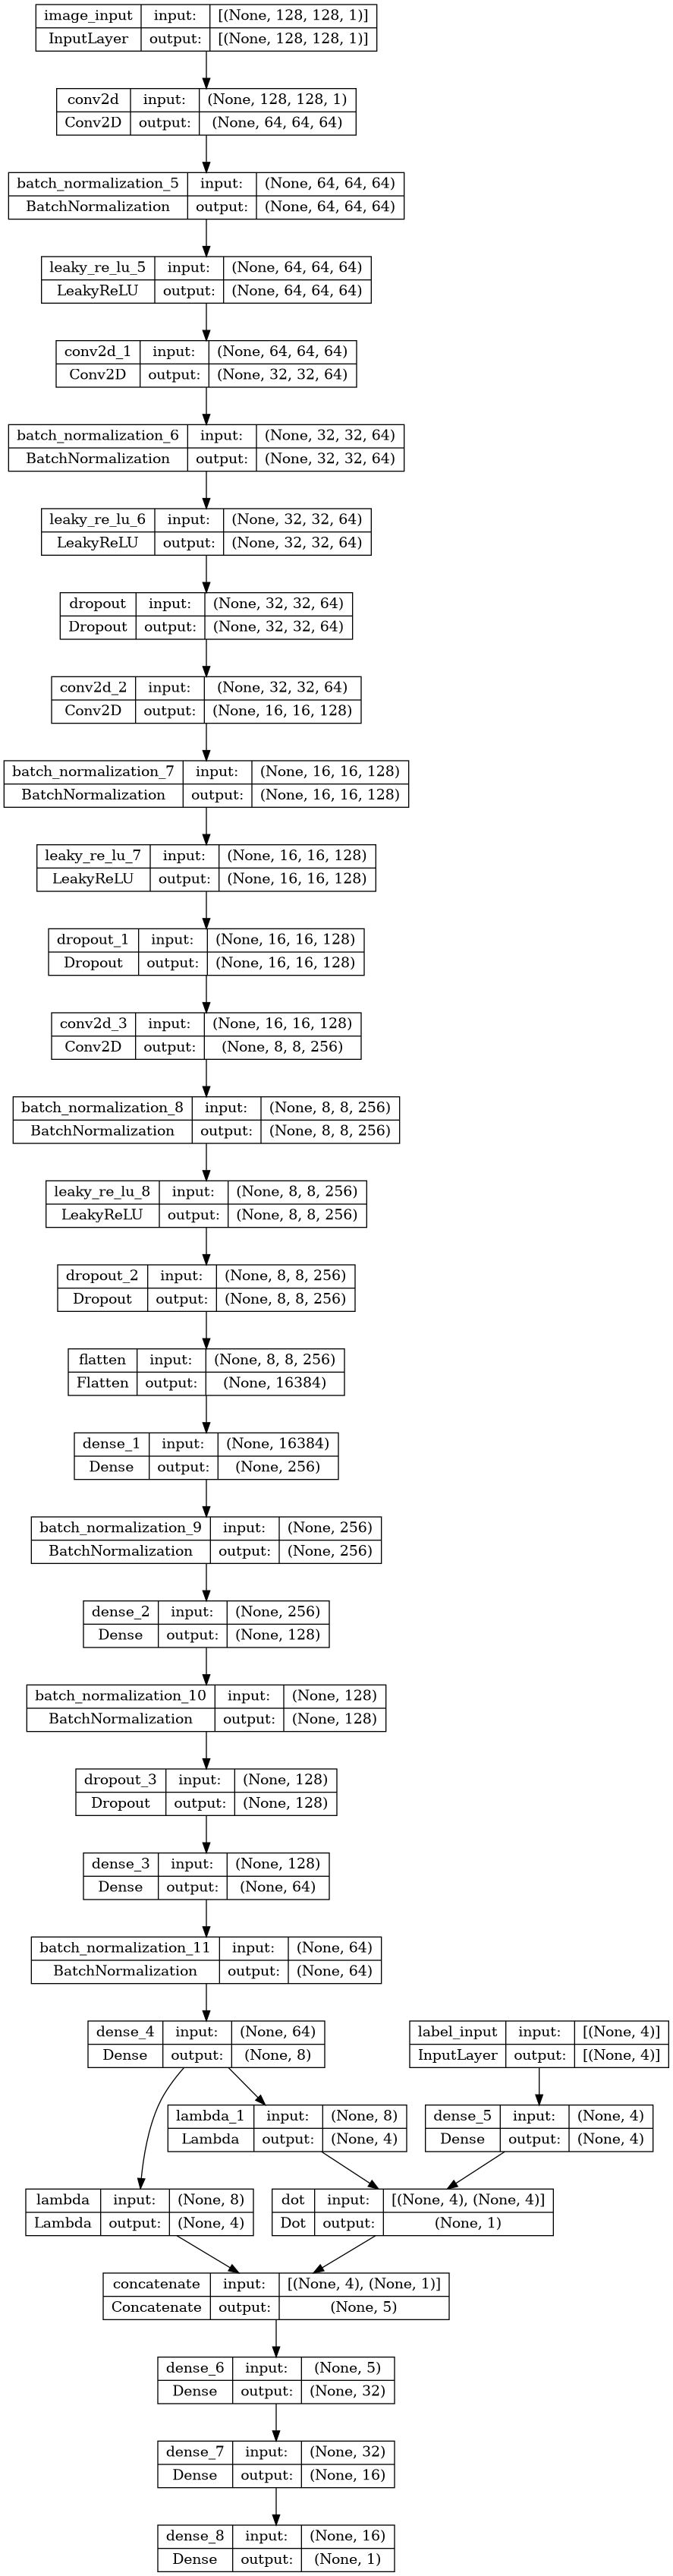

In [14]:
discriminator = dis.make_discriminator_model(num_of_labels=num_of_classes)
tf.keras.utils.plot_model(discriminator, show_shapes=True)

In [15]:
decision = discriminator([generated_image,extra_values])
print (decision)

W0000 00:00:1749226592.576453   27561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1749226592.577507   27561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1749226592.578882   27561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1749226592.580111   27561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1749226592.593692   27561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1749226592.594090   27561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1749226592.594537   27561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1749226592.601837   27561 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1749226592.602248   27561 gp

tf.Tensor([[0.5]], shape=(1, 1), dtype=float16)


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


In [16]:
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
checkpoint = tf.train.Checkpoint(generator_optimizer=gen.generator_optimizer,
                                 discriminator_optimizer=dis.discriminator_optimizer,
                                 generator=generator,
                                 discriminator=discriminator)

In [17]:
seed, _ = ut.create_seed(num_examples_to_generate=num_examples_to_generate, noise_dim=noise_dim, num_classes=num_of_classes)
seed.shape

TensorShape([16, 104])

In [18]:
# Ajustável: fração de updates do discriminador por update do gerador (ex: 0.5 = 1 update do disc a cada 2 do gen)
disc_update_ratio = 0.5

disc_update_interval = int(1 / disc_update_ratio)

# Histórico de perdas para plotar ao longo das épocas
g_loss_history = []
d_loss_history = []

In [19]:
def plot_losses(epoch):
    plt.figure(figsize=(8, 4))
    plt.plot(g_loss_history, label='Gerador')
    plt.plot(d_loss_history, label='Discriminador')
    plt.title(f'Histórico de Loss até a Época {epoch}')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [20]:
@tf.function(jit_compile=True)
def train_step(images, labels, step):
    real_batch_size = tf.shape(images)[0]

    noise = tf.random.normal([real_batch_size, noise_dim])
    labels = tf.cast(labels, tf.float32)
    noise = tf.concat([noise, labels], axis=1)

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator([images, labels], training=True)
        fake_output = discriminator([generated_images, labels], training=True)

        gen_loss = gen.generator_loss(fake_output)
        disc_loss = dis.discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gen.generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))

    if tf.equal(step % disc_update_interval, 0):
        gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
        dis.discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [21]:
def train(dataset, epochs, file_writer):
    start_training_time = time.time()
    step = tf.Variable(0, dtype=tf.int64)
    for epoch in range(epochs):
        start_epoch_time = time.time()

        epoch_gen_loss = 0.0
        epoch_disc_loss = 0.0
        num_batches = 0

        for image_batch, label_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch, label_batch, step)

            with file_writer.as_default():
                tf.summary.scalar('Loss_Gerador_batch', gen_loss, step=step)
                tf.summary.scalar('Loss_Discriminador_batch', disc_loss, step=step)

            epoch_gen_loss += gen_loss
            epoch_disc_loss += disc_loss

            step.assign_add(1)
            num_batches += 1

        avg_gen_loss = epoch_gen_loss / num_batches
        avg_disc_loss = epoch_disc_loss / num_batches
        g_loss_history.append(avg_gen_loss.numpy())
        d_loss_history.append(avg_disc_loss.numpy())

        display.clear_output(wait=True)
        plot_losses(epoch + 1)

        ut.generate_and_save_images(generator, epoch + 1, seed, train_image_out_path, num_classes=num_of_classes)

        images = generator(seed, training=False)
        with file_writer.as_default():
            tf.summary.scalar('Loss_Gerador_media_epoca', avg_gen_loss, step=epoch)
            tf.summary.scalar('Loss_Discriminador_media_epoca', avg_disc_loss, step=epoch)
            img_sample = (images * 0.5) + 0.5
            tf.summary.image('Imagens_Geradas', img_sample, max_outputs=4, step=epoch)

        print(f'Época {epoch + 1}/{epochs} | Loss G: {avg_gen_loss.numpy():.4f}, D: {avg_disc_loss.numpy():.4f}, Tempo: {time.time() - start_epoch_time:.2f}s')

        if (epoch + 1) % 15 == 0:
            checkpoint.save(file_prefix=checkpoint_prefix)

    print(f'Treinamento completo após {epochs} épocas e {time.time() - start_training_time:.2f} segundos.')

In [22]:
file_writer = tf.summary.create_file_writer(log_dir)

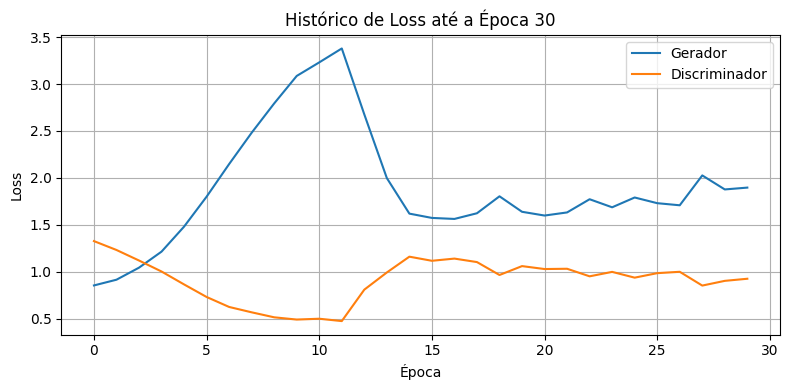

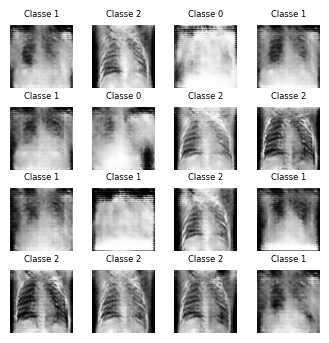

Época 30/30 | Loss G: 1.8955, D: 0.9238, Tempo: 4.01s
Treinamento completo após 30 épocas e 162.80 segundos.


In [23]:
train(train_dataset, EPOCHS, file_writer=file_writer)

Restore the latest checkpoint.

In [24]:
checkpoint.restore(tf.train.latest_checkpoint(checkpoint_dir))

In [25]:
fps = 30

with imageio.get_writer(out_path / "gan.gif", mode='I', fps=fps) as writer:
    # Obtenha a lista de arquivos de imagem
    filenames = sorted(train_image_out_path.glob('image*.png'))
    for filename in filenames:
        # Leia a imagem
        image = imageio.imread(filename)
        # Adicione a imagem ao GIF
        writer.append_data(image)

In [26]:
try:
    generator.save(os.path.join(model_save_path, 'generator_model.keras'))
#    discriminator.save(os.path.join(save_dir, 'discriminator_model.keras'))
    print(f"Modelo salvo com sucesso em {model_save_path}")
except Exception as e:
    print(f"Erro ao salvar modelo completo: {e}")
    print("Tentando salvar apenas os pesos...")
    try:
        generator.save_weights(os.path.join(model_save_path, 'generator_weights.weights.h5'))
#        discriminator.save_weights(os.path.join(save_dir, 'discriminator_weights.weights.h5'))
        print(f"Pesos do modelo salvos com sucesso em {model_save_path}")
    except Exception as e_weights:
        print(f"Erro ao salvar apenas os pesos: {e_weights}")

Modelo salvo com sucesso em /tf/data_project/image/covid/models/generation_models
